## Экстрактим фичи из картинок при помощи [SIFT](https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html)

In [1]:
import sys
sys.path.append('../..')

%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report
from tqdm import tqdm
import numpy as np
from sklearn.model_selection import train_test_split

from src.model.feature_extraction import extract_hog_features


In [3]:
from src.data.utils.eda_utils import directory_to_dataframe
from src.data.utils.filter_dataset import filter_dataset


# Собираем пути до картинок в датафрейм
# Дальше будем итерироваться по датафрейму, извлекать признаки картинок, а потом мэтчить картинки на основе этих фичей
path_to_dataset = Path("../../data/01_raw/sneakers-dataset")
df = directory_to_dataframe(path_to_dataset)
# Вычищаем Yeezy Slide, т.к. они не укладываются в наши представления о кроссовках
df = filter_dataset(
    df,
    path_to_dataset,
    class_names_to_remove=['yeezy_slide'],
    bad_images_md_path='../2-exploration/bad_images.md' #Картинки, которые мы признали негодными на этапе EDA
)

df.head()

Отбросили изображений: 12
Осталось изображений: 5796


,path,sneaker_class
0,reebok_classic_leather/0071.jpg,reebok_classic_leather
1,reebok_classic_leather/0065.jpg,reebok_classic_leather
2,reebok_classic_leather/0059.jpg,reebok_classic_leather
3,reebok_classic_leather/0058.jpg,reebok_classic_leather
4,reebok_classic_leather/0064.jpg,reebok_classic_leather


In [4]:
train, test = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

In [5]:
train.set_index('path', inplace=True)
test.set_index('path', inplace=True)

In [6]:
import cv2 as cv

img_path = 'nike_dunk_low/0002.jpg'
img = cv.imread(path_to_dataset / img_path, cv.IMREAD_GRAYSCALE)
img

array([[245, 245, 245, ..., 245, 245, 245],
       [245, 245, 245, ..., 245, 245, 245],
       [245, 245, 245, ..., 245, 245, 245],
       ...,
       [245, 245, 245, ..., 245, 245, 245],
       [245, 245, 245, ..., 245, 245, 245],
       [245, 245, 245, ..., 245, 245, 245]], dtype=uint8)

In [7]:
pd.Series(extract_hog_features(img)).describe()

count    1764.000000
mean        0.073660
std         0.122035
min         0.000000
25%         0.000000
50%         0.005362
75%         0.106010
max         0.820708
dtype: float64

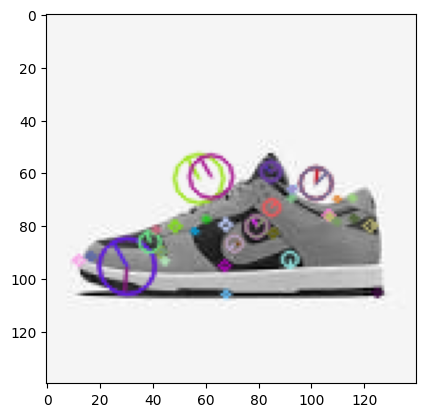

In [8]:
# Для каждого изображения в датафрейме считаем SIFT
sift = cv.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(img, None)
img_with_keypoints = cv.drawKeypoints(img, keypoints, None, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(img_with_keypoints)

In [9]:
feature_df = []
for img_path in train.index:
    img = cv.imread(path_to_dataset / img_path, cv.IMREAD_GRAYSCALE)
    sift = cv.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(img, None)
    descriptors = pd.DataFrame(descriptors)
    descriptors['path'] = img_path
    feature_df.append(descriptors)
feature_df = pd.concat(feature_df)
feature_df

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,path
0,0.0,6.0,26.0,24.0,15.0,57.0,26.0,0.0,0.0,5.0,...,35.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,nike_air_max_90/0055.jpg
1,9.0,5.0,104.0,93.0,0.0,1.0,7.0,4.0,141.0,45.0,...,0.0,81.0,141.0,57.0,0.0,0.0,0.0,0.0,0.0,nike_air_max_90/0055.jpg
2,101.0,67.0,2.0,1.0,10.0,2.0,0.0,0.0,95.0,39.0,...,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,nike_air_max_90/0055.jpg
3,0.0,0.0,6.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,41.0,137.0,1.0,0.0,0.0,0.0,0.0,0.0,nike_air_max_90/0055.jpg
4,0.0,0.0,0.0,4.0,79.0,127.0,17.0,0.0,2.0,0.0,...,11.0,0.0,4.0,49.0,20.0,0.0,0.0,51.0,22.0,nike_air_max_90/0055.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27,6.0,3.0,0.0,1.0,3.0,11.0,17.0,6.0,26.0,5.0,...,8.0,93.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,converse_one_star/0024.jpg
28,66.0,10.0,0.0,0.0,150.0,72.0,0.0,1.0,150.0,19.0,...,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,converse_one_star/0024.jpg
29,10.0,8.0,1.0,3.0,20.0,5.0,2.0,4.0,73.0,45.0,...,7.0,132.0,62.0,4.0,0.0,0.0,0.0,0.0,10.0,converse_one_star/0024.jpg
30,0.0,0.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,3.0,...,123.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,converse_one_star/0024.jpg


In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

feature_df[list(range(128))] = scaler.fit_transform(feature_df[list(range(128))])
n_feats = 200
clustering = KMeans(n_feats)
clustering.fit(feature_df[list(range(128))])
feature_df['cluster_feat'] = clustering.predict(feature_df[list(range(128))]).astype(str)

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/a.r.makarenko/Documents/hse/sneake

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.001s...
[t-SNE] Computed neighbors for 10000 samples in 0.281s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 3.084210


/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/a.r.makarenko/Documents/hse/sneakers-

[t-SNE] KL divergence after 250 iterations with early exaggeration: 94.251083
[t-SNE] KL divergence after 1000 iterations: 2.630974


/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_83357/3664400311.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sample_df[['tsne1', 'tsne2']] = tsne.fit_transform(sample_df[list(range(128))])
/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_83357/3664400311.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sample_df[['tsne1', 'tsne2']] = tsne.fit_transform(sample_df[list(range(128))])


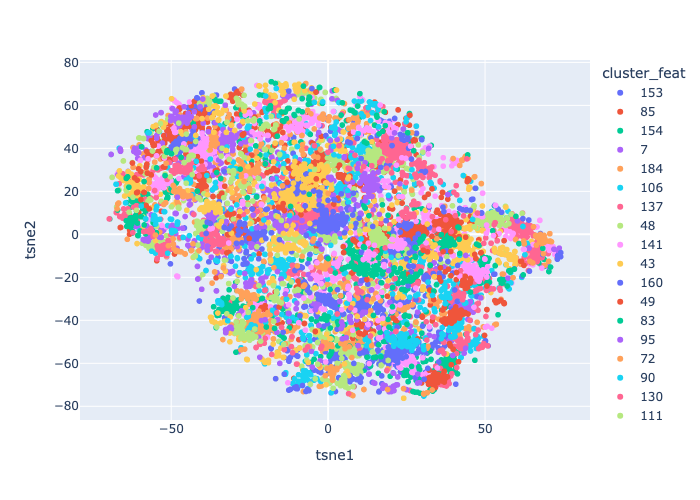

In [11]:
from sklearn.manifold import TSNE
import plotly.express as px
from IPython.display import Image, display


# Assume X is your high-dimensional data matrix and y are labels or target classes
tsne = TSNE(n_components=2, random_state=123, verbose=1)
sample_df = feature_df.sample(10000, random_state=0)
sample_df[['tsne1', 'tsne2']] = tsne.fit_transform(sample_df[list(range(128))])
fig = px.scatter(sample_df, x='tsne1', y='tsne2', color='cluster_feat')
display(Image(fig.to_image('png')))


In [12]:
test_feature_df = []
for img_path in test.index:
    img = cv.imread(path_to_dataset / img_path, cv.IMREAD_GRAYSCALE)
    sift = cv.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(img, None)
    descriptors = pd.DataFrame(descriptors)
    descriptors['path'] = img_path
    test_feature_df.append(descriptors)
test_feature_df = pd.concat(test_feature_df)
test_feature_df

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,path
0,68.0,76.0,4.0,1.0,7.0,22.0,5.0,1.0,167.0,145.0,...,29.0,0.0,0.0,0.0,0.0,2.0,23.0,3.0,0.0,new_balance_574/0039.jpg
1,10.0,2.0,1.0,22.0,79.0,21.0,1.0,1.0,154.0,7.0,...,19.0,0.0,0.0,0.0,0.0,0.0,5.0,6.0,0.0,new_balance_574/0039.jpg
2,10.0,48.0,7.0,4.0,13.0,16.0,0.0,0.0,133.0,76.0,...,100.0,10.0,0.0,0.0,0.0,0.0,7.0,10.0,8.0,new_balance_574/0039.jpg
3,62.0,156.0,2.0,0.0,3.0,21.0,10.0,7.0,62.0,156.0,...,34.0,1.0,1.0,0.0,0.0,0.0,36.0,31.0,1.0,new_balance_574/0039.jpg
4,6.0,1.0,0.0,2.0,5.0,10.0,8.0,5.0,126.0,1.0,...,19.0,1.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,new_balance_574/0039.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335,33.0,45.0,16.0,6.0,6.0,3.0,0.0,3.0,24.0,34.0,...,4.0,0.0,1.0,100.0,88.0,0.0,0.0,2.0,1.0,nike_air_max_90/0121.jpg
336,23.0,0.0,2.0,3.0,2.0,3.0,109.0,129.0,5.0,6.0,...,1.0,38.0,30.0,12.0,5.0,1.0,0.0,2.0,35.0,nike_air_max_90/0121.jpg
337,4.0,14.0,9.0,1.0,0.0,0.0,0.0,0.0,16.0,5.0,...,49.0,22.0,69.0,45.0,12.0,45.0,29.0,13.0,13.0,nike_air_max_90/0121.jpg
338,0.0,0.0,17.0,18.0,12.0,16.0,1.0,0.0,55.0,53.0,...,58.0,5.0,0.0,0.0,0.0,16.0,127.0,127.0,60.0,nike_air_max_90/0121.jpg


In [13]:
test_feature_df[list(range(128))] = scaler.transform(test_feature_df[list(range(128))])
test_feature_df['cluster_feat'] = clustering.predict(test_feature_df[list(range(128))]).astype(str)

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_83357/89987943.py:2: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



In [14]:
train[list(range(n_feats))] = 0
for i, row in tqdm(feature_df.iterrows()):
    train.loc[row['path'], int(row['cluster_feat'])] += 1
train

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_83357/939111233.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_83357/939111233.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_83357/939111233.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.conca

,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
nike_air_max_90/0055.jpg,nike_air_max_90,2,0,1,2,2,0,0,1,0,...,2,1,1,0,0,0,0,1,0,0
nike_cortez/0092.jpg,nike_cortez,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
nike_blazer_mid_77/0083.jpg,nike_blazer_mid_77,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
converse_one_star/0005.jpg,converse_one_star,0,0,0,0,0,0,0,1,0,...,3,0,0,0,3,0,2,1,0,0
nike_air_jordan_11/0047.jpg,nike_air_jordan_11,0,0,0,0,3,0,0,0,1,...,0,0,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
converse_chuck_taylor_all-star_low/0092.jpg,converse_chuck_taylor_all-star_low,1,0,0,0,2,0,0,3,0,...,1,1,0,4,0,1,2,2,0,0
nike_air_force_1_low/0042.jpg,nike_air_force_1_low,1,0,0,0,1,4,0,0,1,...,0,0,1,0,0,1,1,0,0,0
converse_chuck_70_high/0072.jpg,converse_chuck_70_high,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [15]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf = TfidfTransformer()

train[list(range(n_feats))] = tfidf.fit_transform(train[list(range(n_feats))]).toarray()
train

,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
nike_air_max_90/0055.jpg,nike_air_max_90,0.174394,0.0,0.089986,0.174457,0.172707,0.000000,0.000000,0.081967,0.000000,...,0.175476,0.087419,0.078373,0.000000,0.000000,0.000000,0.000000,0.080677,0.00000,0.0
nike_cortez/0092.jpg,nike_cortez,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
nike_blazer_mid_77/0083.jpg,nike_blazer_mid_77,0.000000,0.0,0.000000,0.000000,0.000000,0.094235,0.000000,0.089128,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
converse_one_star/0005.jpg,converse_one_star,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.059531,0.000000,...,0.191166,0.000000,0.000000,0.000000,0.209729,0.000000,0.123152,0.058594,0.00000,0.0
nike_air_jordan_11/0047.jpg,nike_air_jordan_11,0.000000,0.0,0.000000,0.000000,0.292657,0.000000,0.000000,0.000000,0.096826,...,0.000000,0.000000,0.088537,0.000000,0.108741,0.000000,0.000000,0.000000,0.00000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
converse_chuck_taylor_all-star_low/0092.jpg,converse_chuck_taylor_all-star_low,0.051211,0.0,0.000000,0.000000,0.101432,0.000000,0.000000,0.144420,0.000000,...,0.051529,0.051341,0.000000,0.192111,0.000000,0.052869,0.099587,0.094764,0.00000,0.0
nike_air_force_1_low/0042.jpg,nike_air_force_1_low,0.054970,0.0,0.000000,0.000000,0.054438,0.218534,0.000000,0.000000,0.054033,...,0.000000,0.000000,0.049407,0.000000,0.000000,0.056749,0.053448,0.000000,0.00000,0.0
converse_chuck_70_high/0072.jpg,converse_chuck_70_high,0.197161,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.184905,0.000000,0.000000,0.000000,0.000000,0.00000,0.0


In [16]:
test[list(range(n_feats))] = 0
for i, row in tqdm(test_feature_df.iterrows()):
    test.loc[row['path'], int(row['cluster_feat'])] += 1
test

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_83357/3766615880.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_83357/3766615880.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_83357/3766615880.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.co

,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
new_balance_574/0039.jpg,new_balance_574,0,1,1,2,0,0,0,0,1,...,0,0,0,3,0,1,0,1,0,0
nike_air_jordan_11/0041.jpg,nike_air_jordan_11,0,1,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
adidas_ultraboost/0076.jpg,adidas_ultraboost,0,1,1,0,2,0,2,2,0,...,1,0,0,1,0,1,0,0,0,0
vans_old_skool/0036.jpg,vans_old_skool,0,1,1,1,1,2,1,2,0,...,0,0,1,0,0,0,0,1,0,0
nike_air_force_1_low/0115.jpg,nike_air_force_1_low,0,0,0,0,0,0,0,0,0,...,0,0,3,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
new_balance_550/0049.jpg,new_balance_550,0,0,0,1,2,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
salomon_xt-6/0090.jpg,salomon_xt-6,0,1,0,0,1,0,0,0,1,...,0,0,3,1,0,1,0,1,0,0
adidas_gazelle/0067.jpg,adidas_gazelle,0,1,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,1,0,0


In [17]:
test[list(range(n_feats))] = tfidf.transform(test[list(range(n_feats))]).toarray()
test

,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
new_balance_574/0039.jpg,new_balance_574,0.000000,0.081297,0.093224,0.180735,0.000000,0.000000,0.000000,0.000000,0.088796,...,0.000000,0.000000,0.000000,0.254158,0.000000,0.093260,0.0,0.083580,0.000000,0.000000
nike_air_jordan_11/0041.jpg,nike_air_jordan_11,0.000000,0.125593,0.000000,0.000000,0.138207,0.000000,0.000000,0.000000,0.000000,...,0.140422,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
adidas_ultraboost/0076.jpg,adidas_ultraboost,0.000000,0.072754,0.083428,0.000000,0.160122,0.000000,0.166416,0.151989,0.000000,...,0.081344,0.000000,0.000000,0.075817,0.000000,0.083460,0.0,0.000000,0.000000,0.000000
vans_old_skool/0036.jpg,vans_old_skool,0.000000,0.037327,0.042803,0.041492,0.041076,0.082446,0.042690,0.077978,0.000000,...,0.000000,0.000000,0.037280,0.000000,0.000000,0.000000,0.0,0.038375,0.000000,0.000000
nike_air_force_1_low/0115.jpg,nike_air_force_1_low,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.585944,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
new_balance_550/0049.jpg,new_balance_550,0.000000,0.000000,0.000000,0.146945,0.290942,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.157557,0.000000
salomon_xt-6/0090.jpg,salomon_xt-6,0.000000,0.139318,0.000000,0.000000,0.153310,0.000000,0.000000,0.000000,0.152169,...,0.000000,0.000000,0.417425,0.145183,0.000000,0.159819,0.0,0.143231,0.000000,0.000000
adidas_gazelle/0067.jpg,adidas_gazelle,0.000000,0.131286,0.000000,0.000000,0.000000,0.000000,0.300298,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.134973,0.000000,0.000000


In [18]:
train = train.rename(columns=lambda col: f'sift_{col}' if isinstance(col, int) else col)
test = test.rename(columns=lambda col: f'sift_{col}' if isinstance(col, int) else col)

In [19]:
hog_scaler = StandardScaler()
X_hog_train = []
for img_path in tqdm(train.index):
    img = cv.imread(path_to_dataset / img_path, cv.IMREAD_GRAYSCALE)
    X_hog_train.append(extract_hog_features(img))
X_hog_train = np.array(X_hog_train)
train[[f'hog_{i}' for i in range(X_hog_train.shape[1])]] = hog_scaler.fit_transform(X_hog_train)
train

100%|██████████| 4636/4636 [00:00<00:00, 5055.23it/s]
/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_83357/145428863.py:7: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_83357/145428863.py:7: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_83357/145428863.py:7: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance

,sneaker_class,sift_0,sift_1,sift_2,sift_3,sift_4,sift_5,sift_6,sift_7,sift_8,...,hog_1754,hog_1755,hog_1756,hog_1757,hog_1758,hog_1759,hog_1760,hog_1761,hog_1762,hog_1763
path,,,,,,,,,,,,,,,,,,,,,
nike_air_max_90/0055.jpg,nike_air_max_90,0.174394,0.0,0.089986,0.174457,0.172707,0.000000,0.000000,0.081967,0.000000,...,0.208471,0.354641,0.716151,1.034456,1.892019,0.989931,-0.203140,0.175752,-0.184408,-0.133224
nike_cortez/0092.jpg,nike_cortez,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.721438,-0.720278,-0.700658,-0.756169,-0.808264,-0.938749,-0.648662,-0.605895,-0.574944,-0.682289
nike_blazer_mid_77/0083.jpg,nike_blazer_mid_77,0.000000,0.0,0.000000,0.000000,0.000000,0.094235,0.000000,0.089128,0.000000,...,-0.914362,-0.597624,-0.643616,-0.436017,1.446996,1.908949,0.272008,-0.545017,-0.499518,-0.552054
converse_one_star/0005.jpg,converse_one_star,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.059531,0.000000,...,-0.728407,-0.244410,-0.069175,0.165522,-0.623062,-0.873032,-0.567026,-0.282707,-0.449387,-0.393942
nike_air_jordan_11/0047.jpg,nike_air_jordan_11,0.000000,0.0,0.000000,0.000000,0.292657,0.000000,0.000000,0.000000,0.096826,...,-0.935409,-0.720278,-0.700658,-0.756169,-0.808264,-0.938749,-0.648662,-0.605895,-0.574944,-0.682289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
converse_chuck_taylor_all-star_low/0092.jpg,converse_chuck_taylor_all-star_low,0.051211,0.0,0.000000,0.000000,0.101432,0.000000,0.000000,0.144420,0.000000,...,-0.767948,2.123054,2.491898,0.706310,1.594977,0.777769,1.782610,2.752224,1.404832,0.885606
nike_air_force_1_low/0042.jpg,nike_air_force_1_low,0.054970,0.0,0.000000,0.000000,0.054438,0.218534,0.000000,0.000000,0.054033,...,2.145696,2.401572,1.106908,0.171217,0.147248,0.945910,0.143580,-0.528672,-0.177867,2.491477
converse_chuck_70_high/0072.jpg,converse_chuck_70_high,0.197161,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.935409,-0.720278,-0.700658,-0.756169,-0.808264,3.837983,-0.648662,-0.605895,-0.574944,-0.682289


In [20]:
X_hog_test = []
for img_path in tqdm(test.index):
    img = cv.imread(path_to_dataset / img_path, cv.IMREAD_GRAYSCALE)
    X_hog_test.append(extract_hog_features(img))
X_hog_test = np.array(X_hog_test)
test[[f'hog_{i}' for i in range(X_hog_test.shape[1])]] = hog_scaler.transform(X_hog_test)
test

100%|██████████| 1160/1160 [00:00<00:00, 5331.76it/s]
/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_83357/730233187.py:6: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_83357/730233187.py:6: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_83357/730233187.py:6: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance

,sneaker_class,sift_0,sift_1,sift_2,sift_3,sift_4,sift_5,sift_6,sift_7,sift_8,...,hog_1754,hog_1755,hog_1756,hog_1757,hog_1758,hog_1759,hog_1760,hog_1761,hog_1762,hog_1763
path,,,,,,,,,,,,,,,,,,,,,
new_balance_574/0039.jpg,new_balance_574,0.000000,0.081297,0.093224,0.180735,0.000000,0.000000,0.000000,0.000000,0.088796,...,-0.928441,-0.710771,-0.656066,-0.620977,0.082285,2.255605,0.443007,-0.520077,-0.543855,-0.677903
nike_air_jordan_11/0041.jpg,nike_air_jordan_11,0.000000,0.125593,0.000000,0.000000,0.138207,0.000000,0.000000,0.000000,0.000000,...,-0.843466,-0.267232,-0.639475,-0.728016,-0.808264,-0.832260,-0.479640,-0.502195,-0.526371,-0.172183
adidas_ultraboost/0076.jpg,adidas_ultraboost,0.000000,0.072754,0.083428,0.000000,0.160122,0.000000,0.166416,0.151989,0.000000,...,-0.501362,-0.228030,0.351992,0.075268,-0.800913,-0.914494,-0.641265,-0.598616,-0.573894,-0.552095
vans_old_skool/0036.jpg,vans_old_skool,0.000000,0.037327,0.042803,0.041492,0.041076,0.082446,0.042690,0.077978,0.000000,...,0.029254,0.914142,0.759092,0.551551,-0.038675,-0.277512,0.428750,0.971950,0.809459,0.083840
nike_air_force_1_low/0115.jpg,nike_air_force_1_low,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.871598,2.024274,1.666649,0.746861,1.305275,1.389931,-0.250759,-0.462265,-0.313273,1.072417
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
new_balance_550/0049.jpg,new_balance_550,0.000000,0.000000,0.000000,0.146945,0.290942,0.000000,0.000000,0.000000,0.000000,...,-0.935409,-0.720278,-0.700658,-0.756169,-0.808264,-0.938749,-0.648662,-0.605895,-0.574944,-0.682289
salomon_xt-6/0090.jpg,salomon_xt-6,0.000000,0.139318,0.000000,0.000000,0.153310,0.000000,0.000000,0.000000,0.152169,...,-0.462363,-0.666964,-0.644152,-0.732572,-0.767807,-0.860847,-0.640880,-0.554921,-0.546504,-0.669861
adidas_gazelle/0067.jpg,adidas_gazelle,0.000000,0.131286,0.000000,0.000000,0.000000,0.000000,0.300298,0.000000,0.000000,...,3.522223,4.316453,-0.700658,-0.756169,-0.808264,-0.938749,-0.648662,-0.605895,-0.574944,4.438203


In [21]:
from sklearn.svm import LinearSVC, SVC

svc = LinearSVC(loss='squared_hinge', C=1, random_state=42)
sift_feats = [col for col in train.columns if 'sift' in col]
svc.fit(train[sift_feats], train['sneaker_class'])

train['pred'] = svc.predict(train[sift_feats])
print(classification_report(train['sneaker_class'], train['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.49      0.56      0.53       124
                   adidas_forum_low       0.61      0.49      0.54        75
                     adidas_gazelle       0.47      0.60      0.53       116
                      adidas_nmd_r1       0.55      0.54      0.54        69
                       adidas_samba       0.67      0.60      0.63        57
                  adidas_stan_smith       0.41      0.39      0.40       114
                   adidas_superstar       0.57      0.54      0.55        80
                  adidas_ultraboost       0.47      0.54      0.50       121
                 asics_gel-lyte_iii       0.54      0.39      0.46        71
             converse_chuck_70_high       0.68      0.50      0.58        68
              converse_chuck_70_low       0.58      0.61      0.59       109
converse_chuck_taylor_all-star_high       0.72      0.78      0.75        6

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_83357/3270361431.py:7: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



In [28]:
svc = SVC(C=1, random_state=42)
hog_feats = [col for col in train.columns if 'hog' in col]
svc.fit(train[hog_feats], train['sneaker_class'])

test['pred'] = svc.predict(test[hog_feats])
print(classification_report(test['sneaker_class'], test['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.08      0.21      0.11        24
                   adidas_forum_low       0.75      0.19      0.30        16
                     adidas_gazelle       0.45      0.45      0.45        33
                      adidas_nmd_r1       0.73      0.31      0.43        26
                       adidas_samba       0.00      0.00      0.00        16
                  adidas_stan_smith       0.18      0.30      0.22        33
                   adidas_superstar       0.00      0.00      0.00        13
                  adidas_ultraboost       0.50      0.50      0.50        28
                 asics_gel-lyte_iii       0.90      0.45      0.60        20
             converse_chuck_70_high       0.25      0.14      0.18         7
              converse_chuck_70_low       0.24      0.33      0.28        39
converse_chuck_taylor_all-star_high       0.25      0.11      0.15         

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [27]:
svc = SVC(C=1, random_state=42)

svc.fit(train[hog_feats + sift_feats], train['sneaker_class'])

test['pred'] = svc.predict(test[hog_feats + sift_feats])
print(classification_report(test['sneaker_class'], test['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.08      0.21      0.11        24
                   adidas_forum_low       0.75      0.19      0.30        16
                     adidas_gazelle       0.45      0.45      0.45        33
                      adidas_nmd_r1       0.73      0.31      0.43        26
                       adidas_samba       0.00      0.00      0.00        16
                  adidas_stan_smith       0.18      0.30      0.22        33
                   adidas_superstar       0.00      0.00      0.00        13
                  adidas_ultraboost       0.50      0.50      0.50        28
                 asics_gel-lyte_iii       0.90      0.45      0.60        20
             converse_chuck_70_high       0.20      0.14      0.17         7
              converse_chuck_70_low       0.24      0.33      0.28        39
converse_chuck_taylor_all-star_high       0.25      0.11      0.15         

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [26]:
svc = SVC(C=10, random_state=42, kernel='poly', degree=2)

svc.fit(train[hog_feats + sift_feats], train['sneaker_class'])

test['pred'] = svc.predict(test[hog_feats + sift_feats])
print(classification_report(test['sneaker_class'], test['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.24      0.33      0.28        24
                   adidas_forum_low       0.50      0.38      0.43        16
                     adidas_gazelle       0.43      0.45      0.44        33
                      adidas_nmd_r1       0.82      0.35      0.49        26
                       adidas_samba       0.00      0.00      0.00        16
                  adidas_stan_smith       0.44      0.33      0.38        33
                   adidas_superstar       0.18      0.15      0.17        13
                  adidas_ultraboost       0.55      0.43      0.48        28
                 asics_gel-lyte_iii       0.75      0.45      0.56        20
             converse_chuck_70_high       0.00      0.00      0.00         7
              converse_chuck_70_low       0.25      0.21      0.23        39
converse_chuck_taylor_all-star_high       0.17      0.11      0.13         

In [29]:
from sklearn.model_selection import cross_val_score

Cs = [0.1, 1, 10, 100, 1000, 10000]
X = train[hog_feats + sift_feats]
y = train['sneaker_class']
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, random_state=42, kernel='poly', degree=2)
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[0.03235362496745155,
 0.25215679983632777,
 0.3211804393110888,
 0.3211804393110888,
 0.3211804393110888,
 0.3211804393110888]

In [30]:
Cs = [0.1, 1, 10, 100, 1000, 10000]
X = train[hog_feats + sift_feats]
y = train['sneaker_class']
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, random_state=42, kernel='poly', degree=3)
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[0.030197057620057283,
 0.21893715359148902,
 0.3037065710672172,
 0.3037065710672172,
 0.3037065710672172,
 0.3037065710672172]

In [32]:
from sklearn.model_selection import cross_val_score

Cs = [0.1, 1, 10, 100, 1000, 10000]
X = train[hog_feats + sift_feats]
y = train['sneaker_class']
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, random_state=42, kernel='poly', degree=2, class_weight='balanced')
    cv_accuracy.append(cross_val_score(svc, X, y, n_jobs=5).mean())
cv_accuracy

[0.035803993229922254,
 0.2590577688502027,
 0.32139618904140166,
 0.32139618904140166,
 0.32139618904140166,
 0.32139618904140166]

In [33]:
svc = SVC(C=10, random_state=42, kernel='poly', degree=2, class_weight='balanced')

svc.fit(train[hog_feats + sift_feats], train['sneaker_class'])

test['pred'] = svc.predict(test[hog_feats + sift_feats])
print(classification_report(test['sneaker_class'], test['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.24      0.33      0.28        24
                   adidas_forum_low       0.50      0.38      0.43        16
                     adidas_gazelle       0.43      0.45      0.44        33
                      adidas_nmd_r1       0.82      0.35      0.49        26
                       adidas_samba       0.00      0.00      0.00        16
                  adidas_stan_smith       0.44      0.33      0.38        33
                   adidas_superstar       0.18      0.15      0.17        13
                  adidas_ultraboost       0.55      0.43      0.48        28
                 asics_gel-lyte_iii       0.75      0.45      0.56        20
             converse_chuck_70_high       0.00      0.00      0.00         7
              converse_chuck_70_low       0.25      0.21      0.23        39
converse_chuck_taylor_all-star_high       0.17      0.11      0.13         